# Analysis: PCA of Model Feature Spaces

### **Notebook Objective**

This notebook performs a deep-dive analysis into the internal feature spaces of the QRC and Classical ESN models. The goal is to understand the relationship between a model's performance (MSE) and the "effective dimensionality" of its internal state representation.

### **Process**
1.  **Load Data**: Import the main experiment results from the `.csv` file.
2.  **Iterate Profiles**: Loop through each data profile (e.g., Mackey-Glass, NARMA).
3.  **Analyze Best Classical Model**: For each profile, identify the best Classical ESN, regenerate its internal reservoir states, and calculate its effective dimensionality via PCA.
4.  **Analyze All QRC Models**: For each QRC hyperparameter combination, regenerate its quantum feature space and calculate its effective dimensionality. This is done in parallel for efficiency.
5.  **Visualize**: Create a scatter plot of Performance (MSE) vs. Effective Dimensionality for all QRC models, with the best Classical ESN's dimensionality shown as a reference line.

In [1]:
# === IMPORTS AND SETUP ===
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our custom modules
from src.data_generation import (
    mackey_glass,
    generate_arma_data, generate_arma_input_driven_data,
    generate_narma_data, generate_narma_input_driven_data,
    create_io_pairs, make_io_pairs, series_length, slice_series,
)
from src.models import get_classical_reservoir_states # For classical analysis
from src.analysis import get_qrc_feature_space, calculate_effective_dimension # For QRC analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

# Jupyter magic command for automatic reloading of external modules
%load_ext autoreload
%autoreload 2

print("Libraries and modules loaded successfully.")

Libraries and modules loaded successfully.


In [2]:
# === CONFIGURATION AND DATA LOADING ===

# Constants needed for regenerating data (must match the experiment notebook).
# After the CV refactor, TRAIN_FRACTION = 0.8 means "the CV pool" — the first
# 80% of the series, which is what models actually see during final training
# for the test-set evaluation reported in median_test_mse.
TRAIN_FRACTION = 0.8
SEED = 2025
RESULTS_FILENAME = '../data/results_comparative.csv'

# Data profiles config — includes BOTH legacy autoregressive AND new input-driven
# profile names. Only profiles actually present in the CSV are processed; the
# rest are silently skipped. This lets the notebook work with either CSV vintage.
data_profiles_config = [
    {'name': 'Mackey_Glass_(tau=17)',  'generator': mackey_glass,                    'params': {'tau': 17}},
    {'name': 'Mackey_Glass_(tau=30)',  'generator': mackey_glass,                    'params': {'tau': 30}},
    {'name': 'Mackey_Glass_(tau=100)', 'generator': mackey_glass,                    'params': {'tau': 100}},
    # Legacy autoregressive (older CSV)
    {'name': 'ARMA_1_2_stochastic',    'generator': generate_arma_data,              'params': {}},
    {'name': 'NARMA10_Chaotic',        'generator': generate_narma_data,             'params': {'order': 10}},
    {'name': 'NARMA5_Chaotic',         'generator': generate_narma_data,             'params': {'order': 5}},
    # New input-driven (newer CSV)
    {'name': 'ARMA_InputDriven',       'generator': generate_arma_input_driven_data, 'params': {}},
    {'name': 'NARMA10_InputDriven',    'generator': generate_narma_input_driven_data,'params': {'order': 10}},
    {'name': 'NARMA5_InputDriven',     'generator': generate_narma_input_driven_data,'params': {'order': 5}},
]

# Load the results
try:
    results_df = pd.read_csv(RESULTS_FILENAME)
    print(f"Successfully loaded results from '{RESULTS_FILENAME}'.")
    print(f"Profiles in CSV: {sorted(results_df['data_profile'].unique())}")
except FileNotFoundError:
    print(f"ERROR: The file '{RESULTS_FILENAME}' was not found. Please run the experiment notebook first.")
    results_df = pd.DataFrame()

# Compute NMSE columns post-hoc so plots can display NMSE instead of MSE.
if not results_df.empty:
    from src.analysis import compute_nmse_columns
    results_df, var_cache = compute_nmse_columns(
        results_df, train_fraction=TRAIN_FRACTION, n_splits=5,
    )
    print(f"NMSE columns added. Profiles covered: "
          f"{sorted({p for p, _ in var_cache.keys()})}")

Successfully loaded results from '../data/results_comparative.csv'.
Profiles in CSV: ['ARMA_InputDriven', 'Mackey_Glass_(tau=100)', 'Mackey_Glass_(tau=17)', 'Mackey_Glass_(tau=30)', 'NARMA10_InputDriven', 'NARMA5_InputDriven']
NMSE columns added. Profiles covered: ['ARMA_InputDriven', 'Mackey_Glass_(tau=100)', 'Mackey_Glass_(tau=17)', 'Mackey_Glass_(tau=30)', 'NARMA10_InputDriven', 'NARMA5_InputDriven']


DIAGNOSTYKA: Sprawdzanie zmiennych...
SUKCES: 'results_df' zawiera 432 wierszy.
Znaleziono konfiguracje profili: 9 profili.

Przetwarzanie profilu: Mackey_Glass_(tau=17)
--> Znaleziono: 36 wynikow QRC oraz 36 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/36 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/Mackey_Glass_(tau=17)_pca_analysis.png


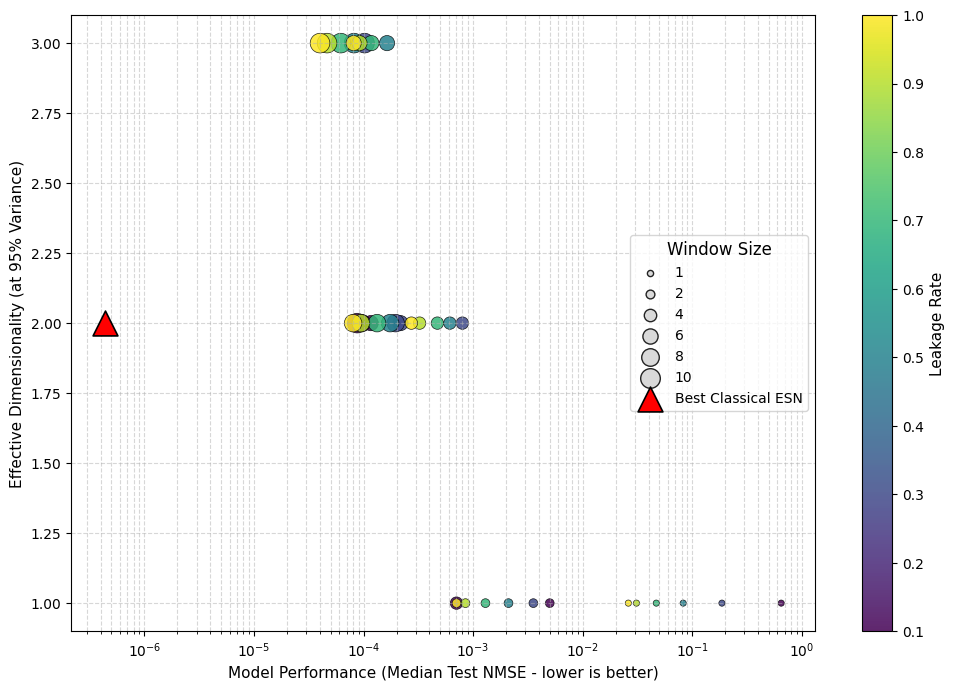


Przetwarzanie profilu: Mackey_Glass_(tau=30)
--> Znaleziono: 36 wynikow QRC oraz 36 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/36 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/Mackey_Glass_(tau=30)_pca_analysis.png


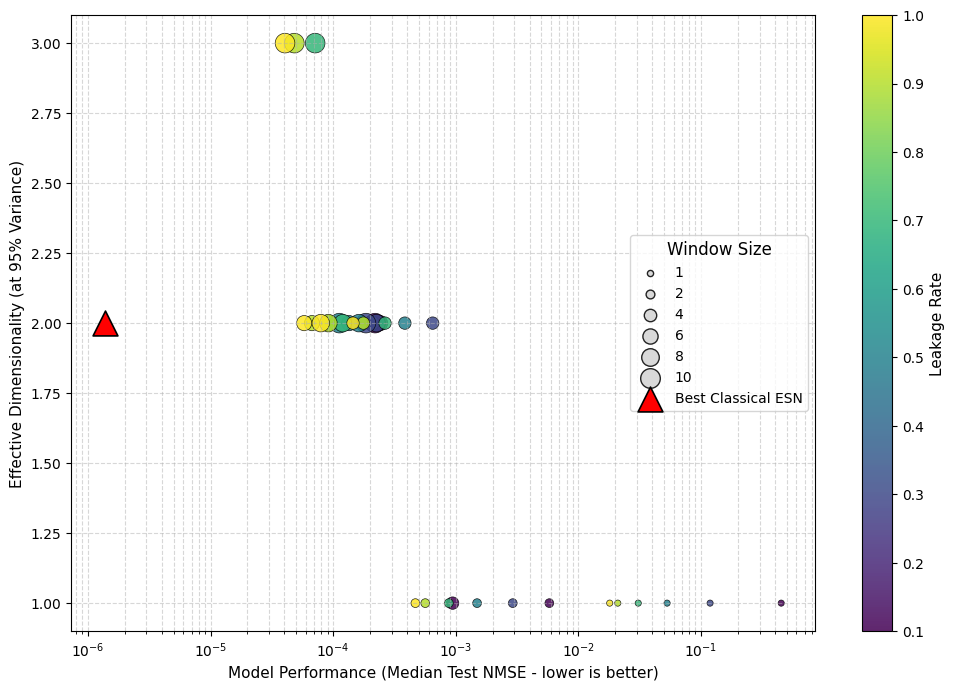


Przetwarzanie profilu: Mackey_Glass_(tau=100)
--> Znaleziono: 36 wynikow QRC oraz 36 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/36 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/Mackey_Glass_(tau=100)_pca_analysis.png


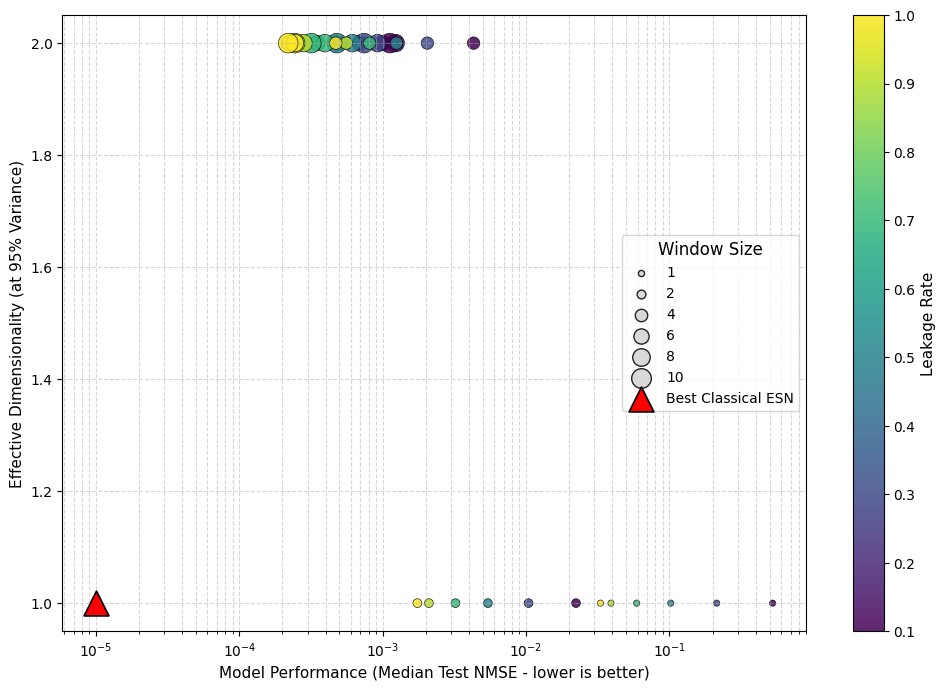


Przetwarzanie profilu: ARMA_1_2_stochastic
--> Znaleziono: 0 wynikow QRC oraz 0 wynikow ESN.
--> POMIJAM: Brak wystarczajacych danych dla 'ARMA_1_2_stochastic'.

Przetwarzanie profilu: NARMA10_Chaotic
--> Znaleziono: 0 wynikow QRC oraz 0 wynikow ESN.
--> POMIJAM: Brak wystarczajacych danych dla 'NARMA10_Chaotic'.

Przetwarzanie profilu: NARMA5_Chaotic
--> Znaleziono: 0 wynikow QRC oraz 0 wynikow ESN.
--> POMIJAM: Brak wystarczajacych danych dla 'NARMA5_Chaotic'.

Przetwarzanie profilu: ARMA_InputDriven
--> Znaleziono: 36 wynikow QRC oraz 36 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/36 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/ARMA_InputDriven_pca_analysis.png


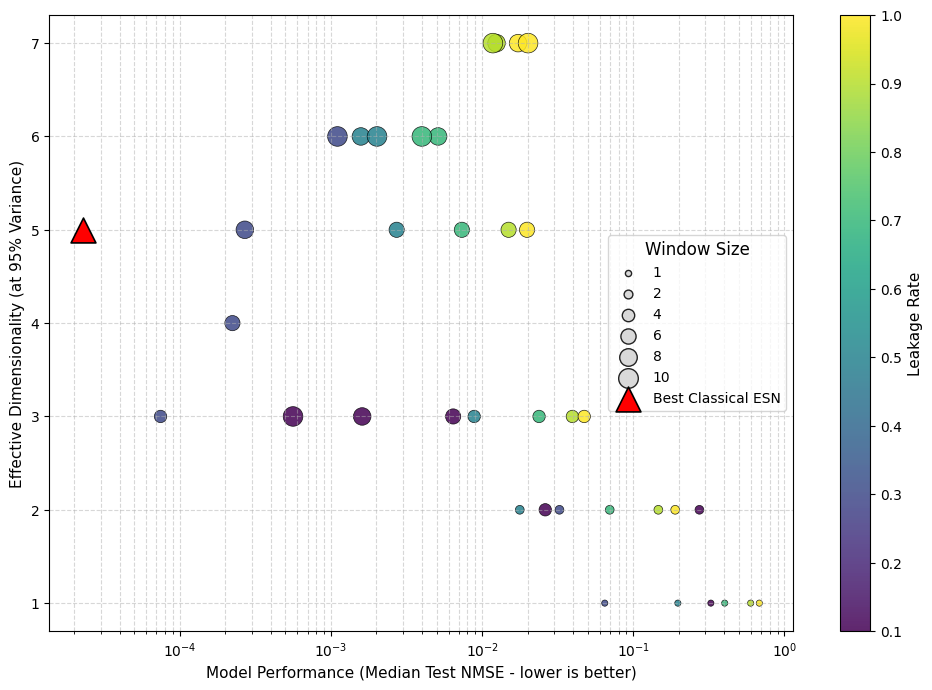


Przetwarzanie profilu: NARMA10_InputDriven
--> Znaleziono: 36 wynikow QRC oraz 36 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/36 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/NARMA10_InputDriven_pca_analysis.png


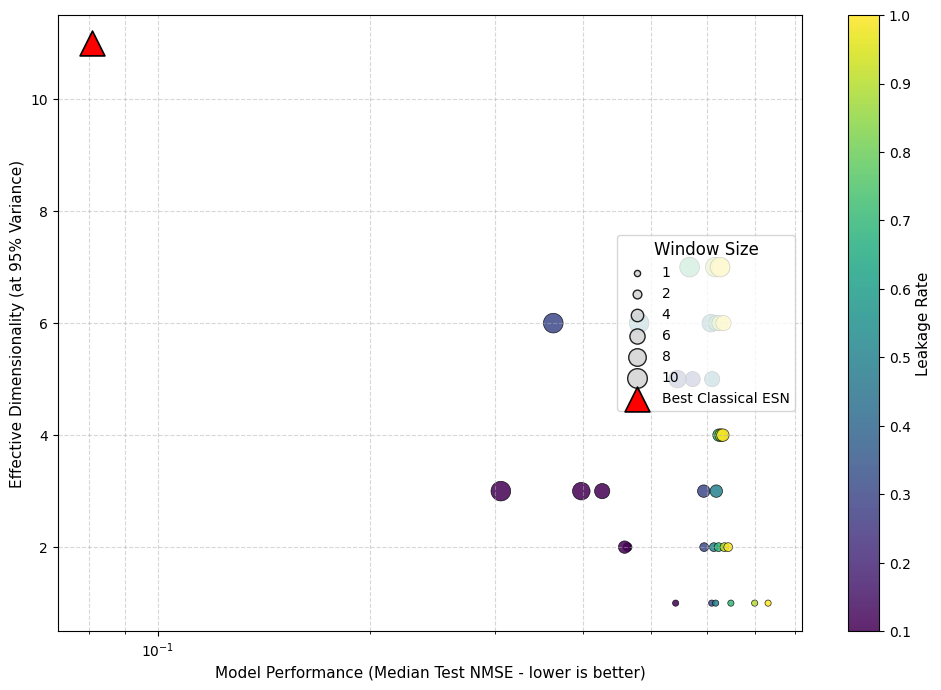


Przetwarzanie profilu: NARMA5_InputDriven
--> Znaleziono: 36 wynikow QRC oraz 36 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/36 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/NARMA5_InputDriven_pca_analysis.png


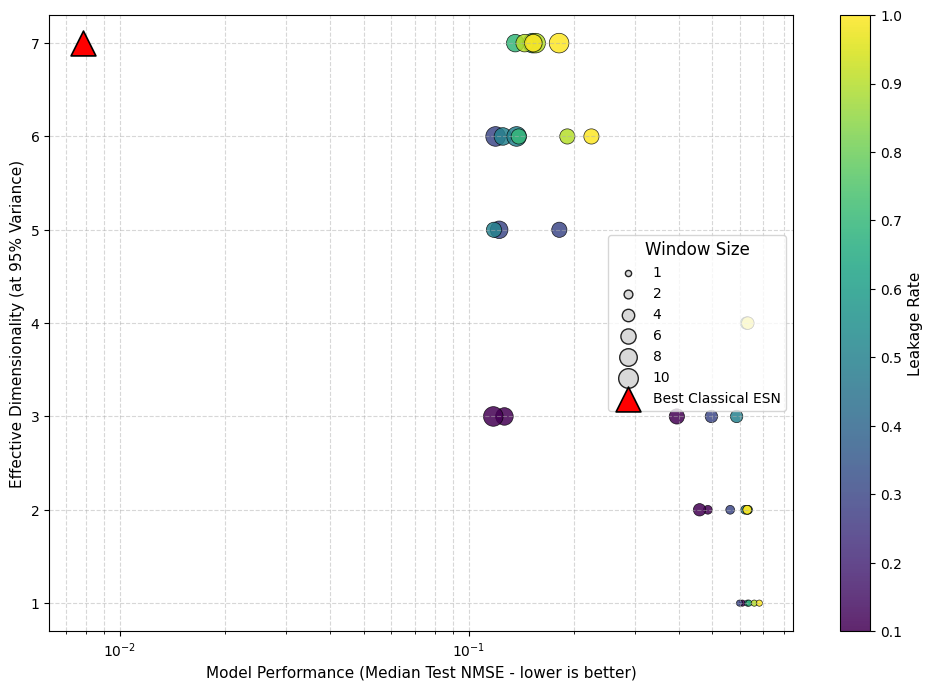


--- ZAKONCZONO ---


In [3]:
# === PCA ANALYSIS AND PLOTTING LOOP ===
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# Upewnijmy sie, ze funkcja pomocnicza jest zdefiniowana
def calculate_eff_dim_for_qrc_row(row, time_series, train_fraction, seed):
    """Wrapper function for joblib parallelization."""
    params_tuple = (
        row['leakage_rate'], row['lambda_reg'],
        int(row['window_size']), int(row['n_layers']), int(row['lag'])
    )
    features = get_qrc_feature_space(params_tuple, time_series, train_fraction, seed)
    return calculate_effective_dimension(features)

# --- DIAGNOSTYKA ---
print(f"DIAGNOSTYKA: Sprawdzanie zmiennych...")
if 'results_df' not in locals():
    print("BLAD KRYTYCZNY: Zmienna 'results_df' nie istnieje! Uruchom poprzednie komorki notebooka.")
elif results_df.empty:
    print("BLAD KRYTYCZNY: 'results_df' jest puste! Sprawdz czy plik CSV zostal wczytany.")
else:
    print(f"SUKCES: 'results_df' zawiera {len(results_df)} wierszy.")

if 'data_profile_config' in locals():
    profiles_to_run = data_profile_config
    print(f"Znaleziono konfiguracje profili: {len(profiles_to_run)} profili.")
elif 'data_profiles_config' in locals():
    profiles_to_run = data_profiles_config
    print(f"Znaleziono konfiguracje profili: {len(profiles_to_run)} profili.")
else:
    try:
        profiles_to_run = data_profiles_config
    except NameError:
        print("BLAD: Nie znaleziono listy 'data_profiles_config'.")
        profiles_to_run = []

# --- GLOWNA PETLA ---
if not results_df.empty and len(profiles_to_run) > 0:
    for profile_config in profiles_to_run:
        profile_name = profile_config['name']
        print(f"\n{'='*60}")
        print(f"Przetwarzanie profilu: {profile_name}")

        # Filtrowanie danych
        profile_df = results_df[results_df['data_profile'] == profile_name]
        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].copy().dropna(subset=['median_cv_mse'])
        classical_df = profile_df[profile_df['model_type'] == 'Classical_ESN'].copy().dropna(subset=['median_cv_mse'])

        print(f"--> Znaleziono: {len(qrc_df)} wynikow QRC oraz {len(classical_df)} wynikow ESN.")

        if qrc_df.empty or classical_df.empty:
            print(f"--> POMIJAM: Brak wystarczajacych danych dla '{profile_name}'.")
            continue

        # Regeneracja szeregu czasowego (dla input-driven zwraca (s, y) tuple)
        print("--> Regeneracja szeregu czasowego...")
        time_series = profile_config['generator'](**profile_config['params'])
        n_total = series_length(time_series)
        train_segment = slice_series(time_series, 0, int(n_total * TRAIN_FRACTION))

        # 1. Analiza klasycznego ESN (selekcja po CV MSE, raport po test MSE)
        print("--> Analiza najlepszego modelu klasycznego...")
        try:
            best_classical_row = classical_df.loc[classical_df['median_cv_mse'].idxmin()]
            classical_win_size = int(best_classical_row.get('window_size', 10))

            # make_io_pairs dispatches on input-driven vs autoregressive
            train_inputs_classical, _ = make_io_pairs(train_segment, classical_win_size)

            classical_states = get_classical_reservoir_states(
                train_inputs=train_inputs_classical,
                reservoir_size=int(best_classical_row['reservoir_size']),
                leakage_rate=best_classical_row['leakage_rate'],
                spectral_radius=best_classical_row['spectral_radius'],
                sparsity=best_classical_row['sparsity'],
                seed=SEED,
                input_dim=classical_win_size
            )

            eff_dim_classical = calculate_effective_dimension(classical_states)
            mse_classical = best_classical_row['median_test_nmse']
        except Exception as e:
            print(f"BLAD przy analizie ESN: {e}")
            continue

        # 2. Analiza QRC (Rownolegla)
        print("--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...")
        effective_dims = Parallel(n_jobs=-1)(
            delayed(calculate_eff_dim_for_qrc_row)(row, time_series, TRAIN_FRACTION, SEED)
            for _, row in tqdm(qrc_df.iterrows(), total=qrc_df.shape[0], desc=f"PCA Analysis")
        )
        qrc_df['effective_dim'] = effective_dims

        # 3. Rysowanie wykresu (kolor: leakage rate -> viridis)
        print("--> Generowanie wykresu...")
        try:
            plt.figure(figsize=(12, 8))

            # QRC Points — x-axis = test MSE, color = leakage_rate, size = window_size
            scatter = plt.scatter(
                qrc_df['median_test_nmse'],
                qrc_df['effective_dim'],
                c=qrc_df['leakage_rate'],
                cmap='viridis',
                alpha=0.85,
                s=qrc_df['window_size'] * 20,
                edgecolors='black',
                linewidth=0.5
            )

            cbar = plt.colorbar(scatter)
            cbar.set_label('Leakage Rate', fontsize=11)

            plt.xlabel('Model Performance (Median Test NMSE - lower is better)', fontsize=11)
            plt.ylabel('Effective Dimensionality (at 95% Variance)', fontsize=11)
            plt.xscale('log')
            plt.grid(True, which="both", ls="--", alpha=0.5)

            # Legenda rozmiarow (window_size)
            size_handles = [plt.scatter([], [], s=size * 20, label=f'{int(size)}',
                                        c='lightgray', alpha=0.85, edgecolors='black')
                            for size in sorted(qrc_df['window_size'].unique())]

            all_handles = size_handles
            plt.legend(handles=all_handles, title='Window Size',
                       loc='center right', fontsize=10, title_fontsize=12)

            # Zapis i wyswietlenie
            filename = f"../reports/figures/{profile_name}_pca_analysis.png"
            plt.savefig(filename, dpi=300)
            print(f"--> Wykres zapisano jako: {filename}")
            plt.show()

        except Exception as e:
            print(f"BLAD podczas rysowania: {e}")

print("\n--- ZAKONCZONO ---")

---

## Probability of concordance — efektywna wymiarowość vs test NMSE

Mierzymy w jakim **procencie par modeli** ten o **wyższej `effective_dim`** ma **niższe test NMSE**.
Wartość > 50% oznacza, że wyższa wymiarowość wiąże się empirycznie z lepszą predykcją;
wartość < 50% oznacza odwrotny związek; 50% = brak monotonicznego trendu.

Statystyka jest powiązana z Kendall's τ przez `concordance = (1 − τ) / 2 × 100%` (chcemy
"wyższy dim ↔ niższy MSE", więc ujemna korelacja rangowa = wysokie concordance).

**Bootstrap 95% CI**: 1000 resampli z powtórzeniami z par `(eff_dim, test_NMSE)` per
profil; CI to 2.5 i 97.5 percentyl rozkładu concordance po resamplowaniu.

**Cumulative**: pula wszystkich par z 6 profili razem (NMSE pozwala na sensowne
zestawienie skali między profilami) — daje jedną liczbę reprezentującą globalny trend.

Dwie tabele osobno dla QRC i klasycznego ESN, zapisane w `../reports/tabele/`.

In [4]:
# === COMPUTE effective_dim AND test NMSE FOR ALL ROWS ===
# Per profile: parallel calculation of effective_dim for every QRC and Classical
# combination, then attach a test-NMSE column using the deterministic target
# variance for (profile, window_size).

import os
import re
from src.experiment import sliding_cv_folds, WASHOUT
from src.data_generation import (create_io_pairs, make_io_pairs,
                                 series_length, slice_series)
from src.models import get_classical_reservoir_states


def calculate_eff_dim_for_classical_row(row, time_series, train_fraction, seed):
    """Effective dimensionality of the classical reservoir feature space."""
    win = int(row['window_size'])
    n = series_length(time_series)
    train_segment = slice_series(time_series, 0, int(n * train_fraction))
    train_inputs, _ = make_io_pairs(train_segment, win)

    states = get_classical_reservoir_states(
        train_inputs=train_inputs,
        reservoir_size=int(row['reservoir_size']),
        leakage_rate=row['leakage_rate'],
        spectral_radius=row['spectral_radius'],
        sparsity=row['sparsity'],
        seed=seed,
        input_dim=win,
    )
    return calculate_effective_dimension(states)


def split_cv_pool_test(ts, train_fraction):
    """Handles both 1D arrays and (s, y) tuples."""
    n = series_length(ts)
    cv_end = int(n * train_fraction)
    return slice_series(ts, 0, cv_end), slice_series(ts, cv_end, n)


def test_var(time_series, window_size):
    _, _test = split_cv_pool_test(time_series, TRAIN_FRACTION)
    _, y = make_io_pairs(_test, window_size)
    return float(np.var(y[WASHOUT:]))


# Accumulators: per-profile DataFrames enriched with effective_dim + test NMSE
qrc_enriched = []
classical_enriched = []

for profile_config in data_profiles_config:
    pname = profile_config['name']
    time_series = profile_config['generator'](**profile_config['params'])

    qrc_sub = results_df[
        (results_df['data_profile'] == pname) &
        (results_df['model_type'] == 'QRC')
    ].dropna(subset=['median_test_mse']).copy()

    cls_sub = results_df[
        (results_df['data_profile'] == pname) &
        (results_df['model_type'] == 'Classical_ESN')
    ].dropna(subset=['median_test_mse']).copy()

    if qrc_sub.empty or cls_sub.empty:
        print(f'--> Skipping {pname}: missing rows')
        continue

    print(f'Processing {pname}: {len(qrc_sub)} QRC + {len(cls_sub)} Classical rows')

    # effective_dim for QRC (parallel)
    qrc_dims = Parallel(n_jobs=-1)(
        delayed(calculate_eff_dim_for_qrc_row)(row, time_series, TRAIN_FRACTION, SEED)
        for _, row in tqdm(qrc_sub.iterrows(), total=len(qrc_sub), desc=f'QRC dim ({pname})')
    )
    qrc_sub['effective_dim'] = qrc_dims

    # effective_dim for Classical (parallel — cheap, but consistent API)
    cls_dims = Parallel(n_jobs=-1)(
        delayed(calculate_eff_dim_for_classical_row)(row, time_series, TRAIN_FRACTION, SEED)
        for _, row in tqdm(cls_sub.iterrows(), total=len(cls_sub), desc=f'Classical dim ({pname})')
    )
    cls_sub['effective_dim'] = cls_dims

    # test NMSE — variance is deterministic per (profile, window_size)
    var_cache = {ws: test_var(time_series, ws)
                 for ws in pd.concat([qrc_sub['window_size'], cls_sub['window_size']]).astype(int).unique()}
    qrc_sub['median_test_nmse'] = qrc_sub.apply(
        lambda r: r['median_test_mse'] / var_cache[int(r['window_size'])], axis=1)
    cls_sub['median_test_nmse'] = cls_sub.apply(
        lambda r: r['median_test_mse'] / var_cache[int(r['window_size'])], axis=1)

    qrc_enriched.append(qrc_sub)
    classical_enriched.append(cls_sub)


qrc_all = pd.concat(qrc_enriched, ignore_index=True)
classical_all = pd.concat(classical_enriched, ignore_index=True)
print(f'\nEnriched: {len(qrc_all)} QRC rows  |  {len(classical_all)} Classical rows')
print(f'QRC effective_dim range:        [{qrc_all["effective_dim"].min()}, {qrc_all["effective_dim"].max()}]')
print(f'Classical effective_dim range:  [{classical_all["effective_dim"].min()}, {classical_all["effective_dim"].max()}]')


Processing Mackey_Glass_(tau=17): 36 QRC + 36 Classical rows


QRC dim (Mackey_Glass_(tau=17)):   0%|          | 0/36 [00:00<?, ?it/s]

Classical dim (Mackey_Glass_(tau=17)):   0%|          | 0/36 [00:00<?, ?it/s]

Processing Mackey_Glass_(tau=30): 36 QRC + 36 Classical rows


QRC dim (Mackey_Glass_(tau=30)):   0%|          | 0/36 [00:00<?, ?it/s]

...

Classical dim (NARMA10_InputDriven):   0%|          | 0/36 [00:00<?, ?it/s]

Processing NARMA5_InputDriven: 36 QRC + 36 Classical rows


QRC dim (NARMA5_InputDriven):   0%|          | 0/36 [00:00<?, ?it/s]

Classical dim (NARMA5_InputDriven):   0%|          | 0/36 [00:00<?, ?it/s]


Enriched: 216 QRC rows  |  216 Classical rows
QRC effective_dim range:        [1, 7]
Classical effective_dim range:  [1, 12]


In [5]:
# === CONCORDANCE PER PROFILE + CUMULATIVE + BOOTSTRAP CI -> LaTeX ===
from scipy.stats import kendalltau

TABELE_DIR = '../reports/tabele'
os.makedirs(TABELE_DIR, exist_ok=True)


def concordance_pct(dim, mse):
    """Probability of concordance: % of pairs where higher dim has lower MSE."""
    dim_arr = np.asarray(dim, dtype=float)
    mse_arr = np.asarray(mse, dtype=float)
    mask = ~(np.isnan(dim_arr) | np.isnan(mse_arr))
    if mask.sum() < 2:
        return np.nan
    tau, _ = kendalltau(dim_arr[mask], mse_arr[mask])
    if np.isnan(tau):
        return np.nan
    return (1.0 - tau) / 2.0 * 100.0


def bootstrap_ci(dim, mse, n_boot=1000, seed=42):
    """Returns (lo, hi) = 2.5 / 97.5 percentile of bootstrap concordance distribution."""
    rng = np.random.default_rng(seed)
    dim_arr = np.asarray(dim, dtype=float)
    mse_arr = np.asarray(mse, dtype=float)
    n = len(dim_arr)
    boot_vals = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        v = concordance_pct(dim_arr[idx], mse_arr[idx])
        if not np.isnan(v):
            boot_vals.append(v)
    if not boot_vals:
        return np.nan, np.nan
    return float(np.percentile(boot_vals, 2.5)), float(np.percentile(boot_vals, 97.5))


def latex_escape(s):
    return (s.replace('\\', r'\textbackslash{}')
             .replace('&', r'\&').replace('%', r'\%')
             .replace('#', r'\#').replace('_', r'\_'))


def safe_filename(name):
    return re.sub(r'[^\w]+', '_', name).strip('_')


def build_concordance_table(df_all, model_label, file_label):
    """Build a 7-row LaTeX table: 6 profiles + cumulative."""
    rows = []
    for pname in df_all['data_profile'].unique():
        sub = df_all[df_all['data_profile'] == pname]
        pct = concordance_pct(sub['effective_dim'].values, sub['median_test_nmse'].values)
        lo, hi = bootstrap_ci(sub['effective_dim'].values, sub['median_test_nmse'].values)
        rows.append({'profile': pname, 'pct': pct, 'lo': lo, 'hi': hi})

    # Cumulative: pool ALL (eff_dim, test_NMSE) pairs across profiles.
    pct_cum = concordance_pct(df_all['effective_dim'].values, df_all['median_test_nmse'].values)
    lo_cum, hi_cum = bootstrap_ci(df_all['effective_dim'].values, df_all['median_test_nmse'].values)

    label = safe_filename(model_label).lower()
    lines = [
        r'\begin{table}[ht]',
        r'\centering',
        rf'\caption{{Probability of concordance dla modelu {model_label}: efektywna wymiarowość vs test NMSE. Bootstrap 95\% CI z 1000 resampli.}}',
        rf'\label{{tab:concordance-{label}}}',
        r'\begin{tabular}{lcc}',
        r'\toprule',
        r'Zbiór danych & Concordance \% & 95\% CI (bootstrap) \\',
        r'\midrule',
    ]
    for r in rows:
        pname_tex = latex_escape(r['profile'])
        if np.isnan(r['pct']):
            lines.append(rf'\texttt{{{pname_tex}}} & \textemdash & \textemdash \\')
        else:
            lines.append(rf'\texttt{{{pname_tex}}} & {r["pct"]:.1f}\% & [{r["lo"]:.1f}, {r["hi"]:.1f}]\% \\')
    lines.append(r'\midrule')
    if np.isnan(pct_cum):
        lines.append(r'\textbf{Wszystkie zbiory (cumulative)} & \textemdash & \textemdash \\')
    else:
        lines.append(rf'\textbf{{Wszystkie zbiory (cumulative)}} & \textbf{{{pct_cum:.1f}\%}} & \textbf{{[{lo_cum:.1f}, {hi_cum:.1f}]\%}} \\')
    lines += [
        r'\bottomrule',
        r'\end{tabular}',
        r'\end{table}',
    ]

    tex = '\n'.join(lines)
    out_path = f'{TABELE_DIR}/concordance_{file_label}.tex'
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(tex)
    print(f'Wrote {out_path}')
    return tex


# --- Build both tables ---
print('--- QRC ---')
qrc_tex = build_concordance_table(qrc_all, 'QRC', 'qrc')
print(qrc_tex)

print('\n--- Classical ESN ---')
cls_tex = build_concordance_table(classical_all, 'Classical ESN', 'classical_esn')
print(cls_tex)


--- QRC ---
Wrote ../reports/tabele/concordance_qrc.tex
\begin{table}[ht]
\centering
\caption{Probability of concordance dla modelu QRC: efektywna wymiarowość vs test NMSE. Bootstrap 95\% CI z 1000 resampli.}
\label{tab:concordance-qrc}
\begin{tabular}{lcc}
\toprule
Zbiór danych & Concordance \% & 95\% CI (bootstrap) \\
\midrule
\texttt{Mackey\_Glass\_(tau=17)} & 87.0\% & [81.7, 90.5]\% \\
\texttt{Mackey\_Glass\_(tau=30)} & 86.9\% & [82.1, 89.8]\% \\
\texttt{Mackey\_Glass\_(tau=100)} & 82.9\% & [76.8, 86.1]\% \\
\texttt{ARMA\_InputDriven} & 75.4\% & [62.9, 84.2]\% \\
\texttt{NARMA10\_InputDriven} & 52.7\% & [39.3, 66.3]\% \\
\texttt{NARMA5\_InputDriven} & 75.2\% & [66.2, 83.2]\% \\
\midrule
\textbf{Wszystkie zbiory (cumulative)} & \textbf{49.2\%} & \textbf{[44.6, 53.9]\%} \\
\bottomrule
\end{tabular}
\end{table}

--- Classical ESN ---
Wrote ../reports/tabele/concordance_classical_esn.tex
\begin{table}[ht]
\centering
\caption{Probability of concordance dla modelu Classical ESN: efektywn

---

## Concordance per `window_size`-bin (kontrolne, eliminacja confoundera)

Globalna concordance(eff_dim, NMSE) może być napędzana przez `window_size`:
więcej qubitów → wyższy potencjalny `effective_dim` ORAZ (zwykle) niższe NMSE.
Po podziale danych na biny per `window_size` różnice w `effective_dim` w obrębie
binu pochodzą wyłącznie z innych zmiennych (głównie `leakage_rate`) — efekt
`window_size` jest stały, więc nie wprowadza zafałszowania.

**Interpretacja**:
- Jeśli concordance > 50% w **każdym** binie → relacja "wyższy eff_dim ↔ niższy NMSE"
  jest autentyczna, nie tylko artefakt rozmiaru okna
- Jeśli concordance ~50% w binach → globalny efekt napędzany głównie przez `window_size`

Tabela: 6 profili × 6 binów `window_size` + mediana z binów per profil + wiersz
zbiorczy "wszystkie zbiory" (concordance na puli wszystkich profili w obrębie
danego `window_size`). Dwie tabele osobno dla QRC i Classical ESN.

Bootstrap CI w nawiasach przy każdej liczbie zwiększyłby szerokość tabeli — dlatego
pokazujemy tylko punkt estymaty per bin, a CI globalny był w poprzedniej sekcji.
Per-bin bootstrap z n=6 wartości daje szerokie przedziały (małe próbki).

In [6]:
# === PER-BIN CONCORDANCE TABLE ===
# Concordance(eff_dim, NMSE) computed inside each window_size bin separately.
# Eliminates window_size as a confounder. Reuses concordance_pct() from the
# previous cell.

def build_per_bin_concordance_table(df_all, model_label, file_label):
    profiles = sorted(df_all['data_profile'].unique())
    window_sizes = sorted(df_all['window_size'].astype(int).unique())

    rows_data = []
    for pname in profiles:
        sub = df_all[df_all['data_profile'] == pname]
        per_ws_pcts = []
        for ws in window_sizes:
            sub_ws = sub[sub['window_size'].astype(int) == ws]
            if len(sub_ws) < 2:
                per_ws_pcts.append(np.nan)
                continue
            pct = concordance_pct(
                sub_ws['effective_dim'].values,
                sub_ws['median_test_nmse'].values,
            )
            per_ws_pcts.append(pct)
        rows_data.append({'profile': pname, 'pcts': per_ws_pcts})

    # Cumulative per window_size: pool all profiles together within each ws-bin
    cum_pcts = []
    for ws in window_sizes:
        sub_ws = df_all[df_all['window_size'].astype(int) == ws]
        if len(sub_ws) < 2:
            cum_pcts.append(np.nan)
            continue
        pct = concordance_pct(
            sub_ws['effective_dim'].values,
            sub_ws['median_test_nmse'].values,
        )
        cum_pcts.append(pct)

    # Build LaTeX
    n_ws = len(window_sizes)
    col_spec = 'l' + 'c' * n_ws + 'c'
    header = (r'Zbiór danych & '
              + ' & '.join(rf'$w{{=}}{ws}$' for ws in window_sizes)
              + r' & Mediana \\')

    lines = [
        r'\begin{table}[ht]',
        r'\centering',
        rf'\caption{{Concordance \% per window-size-bin dla modelu {model_label}. Mediana z binów = syntetyczna liczba po kontroli rozmiaru okna jako confoundera.}}',
        rf'\label{{tab:concordance-per-bin-{file_label}}}',
        r'\begin{tabular}{' + col_spec + '}',
        r'\toprule',
        header,
        r'\midrule',
    ]

    def fmt_cell(p):
        return r'\textemdash' if np.isnan(p) else f'{p:.0f}\\%'

    for row in rows_data:
        pname_tex = latex_escape(row['profile'])
        cells = [fmt_cell(p) for p in row['pcts']]
        valid = [p for p in row['pcts'] if not np.isnan(p)]
        median_str = (rf'\textbf{{{np.median(valid):.0f}\%}}'
                      if valid else r'\textemdash')
        lines.append(rf'\texttt{{{pname_tex}}} & '
                     + ' & '.join(cells)
                     + rf' & {median_str} \\')

    # Cumulative row
    lines.append(r'\midrule')
    cum_cells = [fmt_cell(p) for p in cum_pcts]
    valid_cum = [p for p in cum_pcts if not np.isnan(p)]
    cum_med_str = (rf'\textbf{{{np.median(valid_cum):.0f}\%}}'
                   if valid_cum else r'\textemdash')
    lines.append(rf'\textbf{{Wszystkie zbiory}} & '
                 + ' & '.join(cum_cells)
                 + rf' & {cum_med_str} \\')

    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']

    tex = '\n'.join(lines)
    out_path = f'{TABELE_DIR}/concordance_per_bin_{file_label}.tex'
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(tex)
    print(f'Wrote {out_path}')
    return tex


print('--- QRC per-bin ---\n')
qrc_pb_tex = build_per_bin_concordance_table(qrc_all, 'QRC', 'qrc')
print(qrc_pb_tex)
print('\n--- Classical ESN per-bin ---\n')
cls_pb_tex = build_per_bin_concordance_table(classical_all, 'Classical ESN', 'classical_esn')
print(cls_pb_tex)

--- QRC per-bin ---

Wrote ../reports/tabele/concordance_per_bin_qrc.tex
\begin{table}[ht]
\centering
\caption{Concordance \% per window-size-bin dla modelu QRC. Mediana z binów = syntetyczna liczba po kontroli rozmiaru okna jako confoundera.}
\label{tab:concordance-per-bin-qrc}
\begin{tabular}{lccccccc}
\toprule
Zbiór danych & $w{=}1$ & $w{=}2$ & $w{=}4$ & $w{=}6$ & $w{=}8$ & $w{=}10$ & Mediana \\
\midrule
\texttt{ARMA\_InputDriven} & \textemdash & \textemdash & 56\% & 28\% & 18\% & 7\% & \textbf{23\%} \\
\texttt{Mackey\_Glass\_(tau=100)} & \textemdash & \textemdash & \textemdash & \textemdash & \textemdash & \textemdash & \textemdash \\
\texttt{Mackey\_Glass\_(tau=17)} & \textemdash & \textemdash & 67\% & 68\% & \textemdash & 67\% & \textbf{67\%} \\
\texttt{Mackey\_Glass\_(tau=30)} & \textemdash & \textemdash & 79\% & \textemdash & \textemdash & 89\% & \textbf{84\%} \\
\texttt{NARMA10\_InputDriven} & \textemdash & \textemdash & 7\% & 7\% & 5\% & 7\% & \textbf{7\%} \\
\texttt{NARMA5\_